EDA для датасета Default of Credit Card Clients (UCI).

Цель: 
Понять структуру данных, распределение признаков, наличие выбросов и корреляции,  
а также подготовить основу для построения признаков и модели скоринга.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Настройки отображения
pd.set_option("display.max_columns", None)
sns.set(style="whitegrid", palette="muted", font_scale=1.1)

DATA_PATH = Path("data/processed/credit_data_processed.csv")

# Загрузка
df = pd.read_csv(DATA_PATH)
print("Размерность данных:", df.shape)
df.head()


Размерность данных: (30000, 25)


,id,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6,bill_amt1,bill_amt2,bill_amt3,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,default_payment_next_month
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


Общие сведения о датасете.
Он состоит из 30 000 наблюдений, каждое из которых представляет отдельного клиента кредитной карты. Каждое наблюдение содержит 24 атрибута, которые включают информацию о дефолтах по платежам, демографических данных, кредитной истории, истории платежей и данных выписок со счетов клиентов кредитных карт на Тайване с апреля по сентябрь 2005 года.

Первая группа переменных содержит личную информацию о клиенте:

ID: Идентификатор каждого клиента.

LIMIT_BAL: Размер предоставленного кредита в новых тайваньских долларах (включает индивидуальный и семейный/дополнительный кредит).

SEX: Пол, категориальная переменная (1=мужчина, 2=женщина).

EDUCATION: Уровень образования, категориальная переменная (1=аспирантура, 2=университет, 3=средняя школа, 4=другое, 5=неизвестно, 6=неизвестно).

MARRIAGE: Семейное положение, категориальная переменная (1=женат/замужем, 2=холост/не замужем, 3=другое).

AGE: Возраст в годах, числовая переменная.

Следующие атрибуты содержат информацию о задержке прошлых платежей, относящуюся к конкретному месяцу:

PAY_0: Статус погашения в сентябре 2005 года (-1=платеж произведен вовремя, 1=задержка платежа на один месяц, 2=задержка платежа на два месяца, … 8=задержка платежа на восемь месяцев, 9=задержка платежа на девять месяцев и более).

PAY_2: Статус погашения в августе 2005 года (та же шкала, что и выше).

PAY_3: Статус погашения в июле 2005 года (та же шкала, что и выше).

PAY_4: Статус погашения в июне 2005 года (та же шкала, что и выше).

PAY_5: Статус погашения в мае 2005 года (та же шкала, что и выше).

PAY_6: Статус погашения в апреле 2005 года (та же шкала, что и выше).

Другие переменные содержат информацию, связанную с суммой выписки (т.е. ежемесячного отчета, который эмитенты кредитных карт выдают держателям карт в конкретном месяце):

BILL_AMT1: Сумма выписки за сентябрь 2005 года (в новых тайваньских долларах).

BILL_AMT2: Сумма выписки за август 2005 года (в новых тайваньских долларах).

BILL_AMT3: Сумма выписки за июль 2005 года (в новых тайваньских долларах).

BILL_AMT4: Сумма выписки за июнь 2005 года (в новых тайваньских долларах).

BILL_AMT5: Сумма выписки за май 2005 года (в новых тайваньских долларах).

BILL_AMT6: Сумма выписки за апрель 2005 года (в новых тайваньских долларах).

Следующие переменные, в свою очередь, отражают сумму предыдущего платежа в конкретном месяце:

PAY_AMT1: Сумма предыдущего платежа в сентябре 2005 года (в новых тайваньских долларах).

PAY_AMT2: Сумма предыдущего платежа в августе 2005 года (в новых тайваньских долларах).

PAY_AMT3: Сумма предыдущего платежа в июле 2005 года (в новых тайваньских долларах).

PAY_AMT4: Сумма предыдущего платежа в июне 2005 года (в новых тайваньских долларах).

PAY_AMT5: Сумма предыдущего платежа в мае 2005 года (в новых тайваньских долларах).

PAY_AMT6: Сумма предыдущего платежа в апреле 2005 года (в новых тайваньских долларах).

In [2]:
# Обшая информация
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          30000 non-null  int64  
 1   limit_bal                   30000 non-null  float64
 2   sex                         30000 non-null  int64  
 3   education                   30000 non-null  int64  
 4   marriage                    30000 non-null  int64  
 5   age                         30000 non-null  int64  
 6   pay_0                       30000 non-null  int64  
 7   pay_2                       30000 non-null  int64  
 8   pay_3                       30000 non-null  int64  
 9   pay_4                       30000 non-null  int64  
 10  pay_5                       30000 non-null  int64  
 11  pay_6                       30000 non-null  int64  
 12  bill_amt1                   30000 non-null  float64
 13  bill_amt2                   300

In [3]:
df.describe()

,id,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6,bill_amt1,bill_amt2,bill_amt3,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,default_payment_next_month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,-0.291100,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,1.149988,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [4]:
df.isna().sum().sort_values(ascending=False).head(10)

id           0
limit_bal    0
sex          0
education    0
marriage     0
age          0
pay_0        0
pay_2        0
pay_3        0
pay_4        0
dtype: int64

C:\Users\mcher\AppData\Local\Temp\ipykernel_22200\3142237236.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  graphic = sns.countplot(x=target, data=df, palette=['#0000ff', '#ff8c00'])


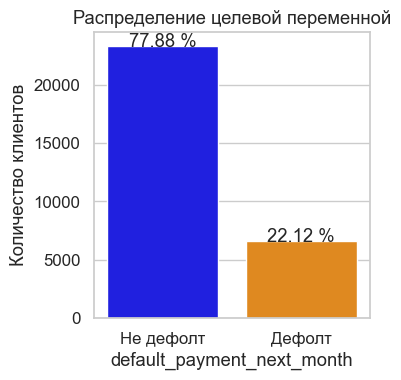

In [26]:
# Распределение целевой переменной

plt.figure(figsize=(4, 4))
target = "default_payment_next_month"
graphic = sns.countplot(x=target, data=df, palette=['#0000ff', '#ff8c00'])

i = 0
for p in graphic.patches:
    height = p.get_height()
    percentage = round(100 * df[target].value_counts()[i] / len(df),2)
    str_plot = f'{percentage} %'
    graphic.text(p.get_x() + p.get_width()/2., height - 100, str_plot, ha="center")
    i += 1
    
plt.title("Распределение целевой переменной")
plt.xticks([0,1],['Не дефолт', 'Дефолт'])
plt.ylabel('Количество клиентов')
plt.tight_layout()


Видим сильный дисбаланс классов. Всего для 22% предсказывается дефолт в следующем месяце.



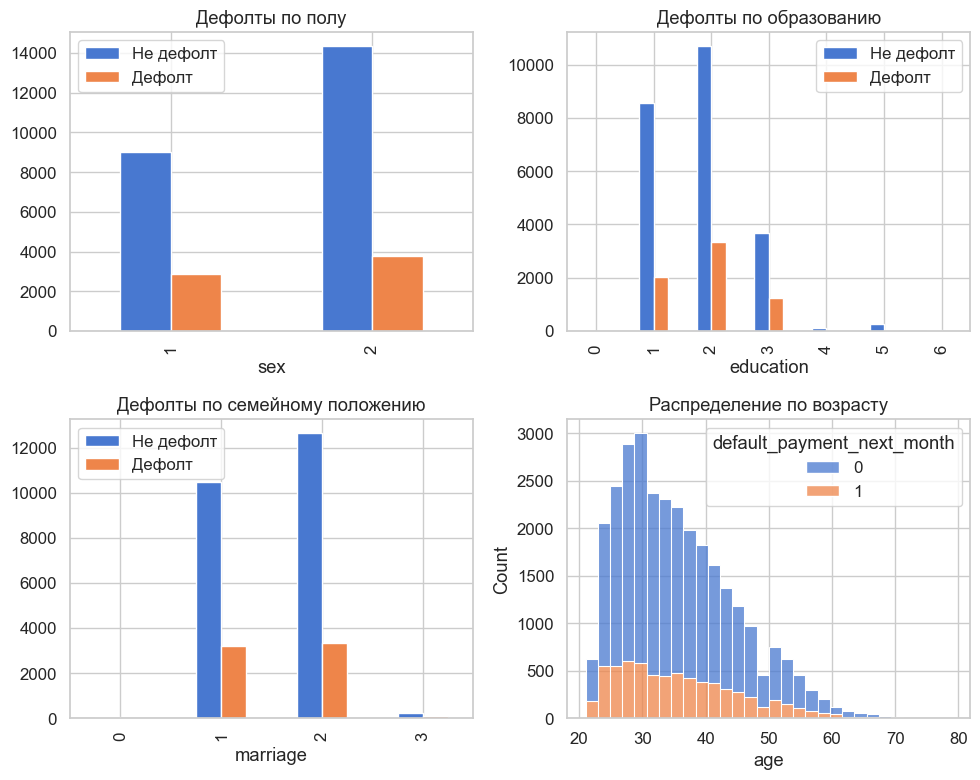

In [24]:
plt.figure(figsize=(10, 8))

# График 1 - Пол
ax1 = plt.subplot(2, 2, 1)
df.groupby(['sex', target]).size().unstack().plot(kind='bar', ax=ax1)
ax1.set_title('Дефолты по полу')
ax1.legend(['Не дефолт', 'Дефолт'])

# График 2 - Образование
ax2 = plt.subplot(2, 2, 2)
df.groupby(['education', target]).size().unstack().plot(kind='bar', ax=ax2)
ax2.set_title('Дефолты по образованию')
ax2.legend(['Не дефолт', 'Дефолт'])

# График 3 - Семейное положение
ax3 = plt.subplot(2, 2, 3)
df.groupby(['marriage', target]).size().unstack().plot(kind='bar', ax=ax3)
ax3.set_title('Дефолты по семейному положению')
ax3.legend(['Не дефолт', 'Дефолт'])

# График 4 - Возраст
ax4 = plt.subplot(2, 2, 4)
sns.histplot(data=df, x='age', hue=target, bins=30, multiple="stack", ax=ax4)
ax4.set_title('Распределение по возрасту')

plt.tight_layout()
plt.show()

In [33]:
# Статистика по полу
sex_analysis = df.groupby('sex').agg({
    target: ['mean', 'count'],
    'limit_bal': 'mean'
}).round(3)

print("Анализ по полу:")
print(sex_analysis)

Анализ по полу:
    default_payment_next_month          limit_bal
                          mean  count        mean
sex                                              
1                        0.242  11888  163519.825
2                        0.208  18112  170086.462


Исходя из графиков и простого анализа можно сказать, что:

a) Большинсвто клиентов - женщины (2)


б) Мужчины имеют более высокую вероятность дефолта (м.б. мужчины более склонны к рискованному финансированию)
В любом случае пол не является определяющим фактором, вляющим на дефолт, однако его следует учитывать.

In [35]:
# Статистика по образованию
education_groups = {
    1: 'Высшее (аспирантура)',
    2: 'Высшее (университет)', 
    3: 'Среднее',
    4: 'Другое',
    5: 'Неизвестно',
    6: 'Неизвестно'
}

edu_analysis = df.groupby('education').agg({
    target: ['mean', 'count'],
    'limit_bal': 'mean',
    'age': 'mean'
}).round(2)

print(edu_analysis)

          default_payment_next_month         limit_bal    age
                                mean  count       mean   mean
education                                                    
0                               0.00     14  217142.86  38.86
1                               0.19  10585  212956.07  34.23
2                               0.24  14030  147062.44  34.72
3                               0.25   4917  126550.27  40.30
4                               0.06    123  220894.31  33.85
5                               0.06    280  168164.29  35.60
6                               0.16     51  148235.29  43.90


Тут результаты уже более интересные. Как можно видеть - наибольшая вероятность дефолта у людей из категории 3 - 25% (Среднее образование). Исходя из данных можно седлать вывод, что чем выше уровень образования клиента - тем ниже риск дефолта. Так же можем видеть, что банк уже учитывает образование при установлении лимитов по кредитам:


Аспирантура (1): 212_956,


Университет (2): 147_062, 


Среднее (3): 126_550,


Другое (4): 220_894,


Неизвестно (5): 168_164,


Неизвестно (6): 148_235

Ещё раз подтверждается значимость уровня образования. Однако результаты для групп 0, 4 - 6 являются достаточно странными. В каждой из групп находится очень небольшое кол-во людей. В группе 4 всего 123 клиента. Для них установлен достаточно высокий кредитный лимит, а риск дефолта низкий. Можно предположить, что людьми из этой группы являются клиенты, не имеющие формального образования, однако владеющие большими финансовыми средствами (возможно какие-то предприниматели)

Группы 5 и 6 аномальны. Идентифицируются одинаково, однако шанс дефолта для них разный (для шестой группы вероятность много больше), чего быть не должно. Возможно это является проблемой качества данных.

Группа 0 тоже аномальна. Включает в себя всего 14 человек, обладает нулевым шансом дефолта, что само по себе странно. Необходим более подробный анализ.

In [39]:
# Детальный анализ 14 клиентов
edu_0_clients = df[df['education'] ==  0].copy()

suspect_analysis = edu_0_clients[[
    'id', 'limit_bal', 'age', 'sex', 'marriage', 
    'pay_0', 'pay_2', 'pay_3', 'bill_amt1'
]]

print("Детальный анализ клиентов с EDUCATION=0:")
print(suspect_analysis)

Детальный анализ клиентов с EDUCATION=0:
          id  limit_bal  age  sex  marriage  pay_0  pay_2  pay_3  bill_amt1
3769    3770   290000.0   38    2         2      1     -1     -1        0.0
5945    5946   270000.0   39    1         2      1     -1     -1        0.0
6876    6877   360000.0   30    1         2      0      0     -1    40250.0
14631  14632   350000.0   53    2         2     -1     -1     -1     5095.0
15107  15108   210000.0   45    1         2     -2     -2     -2     2563.0
16881  16882   100000.0   37    1         2      0      0     -2     7642.0
16896  16897   200000.0   40    1         2      1     -2     -1        0.0
17414  17415   230000.0   47    2         2     -1     -1     -1     8394.0
19920  19921    50000.0   40    2         1      0      0      0    44749.0
20030  20031   200000.0   30    2         2     -1     -1      2    17160.0
23234  23235   220000.0   35    2         1     -2     -2     -2        0.0
24137  24138   150000.0   28    1         2    

In [44]:
# Проверка на дубликаты или аномалии
print(f"Проверка уникальности ID: {edu_0_clients['id'].nunique() == 14}")
print(f"Уникальных ID: {edu_0_clients['id'].nunique()} из {len(edu_0_clients)}")

Проверка уникальности ID: True
Уникальных ID: 14 из 14


In [41]:
# Статистика по этим клиентам
print("Статистика по клиентам с EDUCATION=0:")
print(f"Средний кредитный лимит: {edu_0_clients['limit_bal'].mean():.0f} NT$")
print(f"Средний возраст: {edu_0_clients['age'].mean():.1f} лет")
print(f"Распределение по полу: {edu_0_clients['sex'].value_counts().to_dict()}")
print(f"Распределение по семейному положению: {edu_0_clients['marriage'].value_counts().to_dict()}")
print(f"Количество дефолтов: {edu_0_clients[target].sum()} ({(edu_0_clients[target].sum()/len(edu_0_clients))*100:.1f}%)")

Статистика по клиентам с EDUCATION=0:
Средний кредитный лимит: 217143 NT$
Средний возраст: 38.9 лет
Распределение по полу: {1: 8, 2: 6}
Распределение по семейному положению: {2: 10, 1: 4}
Количество дефолтов: 0 (0.0%)


In [43]:
# Анализ истории платежей
print("Анализ истории платежей (PAY_0):")
print(edu_0_clients['pay_0'].value_counts().sort_index())

Анализ истории платежей (PAY_0):
pay_0
-2    3
-1    4
 0    4
 1    3
Name: count, dtype: int64


In [45]:
# Проверяем, есть ли какие-то общие паттерны
print("Проверка общих характеристик:")
print(f"Минимальный возраст: {edu_0_clients['age'].min()}")
print(f"Максимальный возраст: {edu_0_clients['age'].max()}")
print(f"Минимальный кредитный лимит: {edu_0_clients['limit_bal'].min()}")
print(f"Максимальный кредитный лимит: {edu_0_clients['limit_bal'].max()}")

Проверка общих характеристик:
Минимальный возраст: 28
Максимальный возраст: 53
Минимальный кредитный лимит: 50000.0
Максимальный кредитный лимит: 360000.0


Исходя из анализа этой группы можно предположить, что это либо VIP-клиенты банка, либо другая группа ОСОБЫХ клиентов (сотрудники, клиенты с особыми условиями или тестовые записи). Поскольку данных мало, чтобы не выделять для них отедльную категорию, я совмещю её с 4-ой категорией (другое).

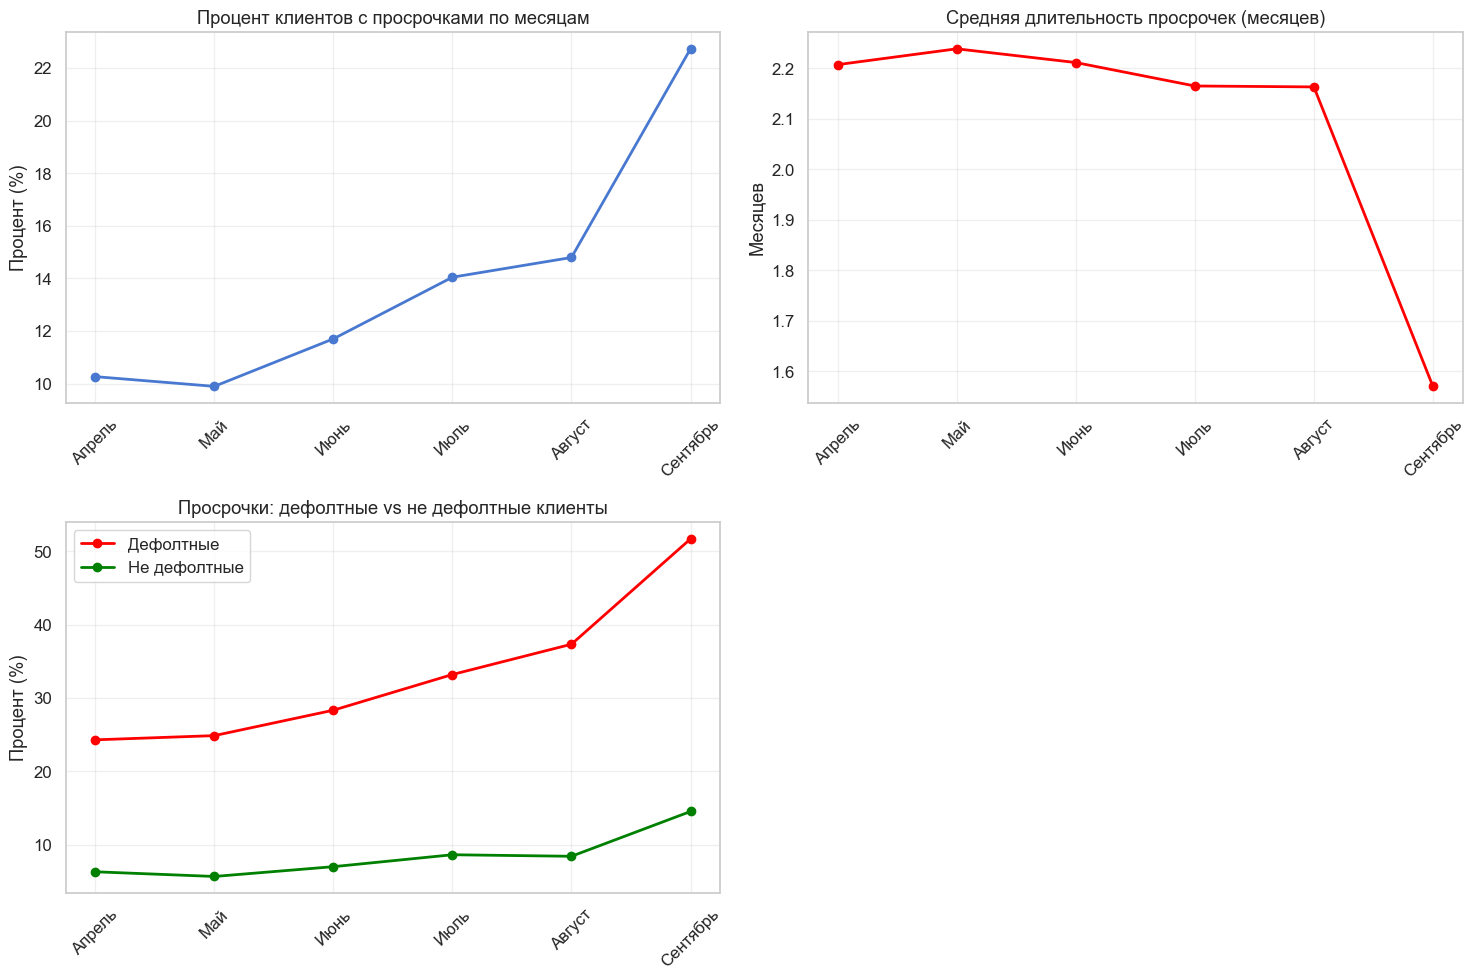

In [49]:
# Динамика просрочек по месяцам
pay_columns = ['pay_6', 'pay_5', 'pay_4', 'pay_3', 'pay_2', 'pay_0']
months = ['Апрель', 'Май', 'Июнь', 'Июль', 'Август', 'Сентябрь']

plt.figure(figsize=(15, 10))

# Процент клиентов с просрочками по месяцам
plt.subplot(2, 2, 1)
late_payments_pct = df[pay_columns].apply(lambda x: (x > 0).mean() * 100)
plt.plot(months, late_payments_pct.values, marker='o', linewidth=2)
plt.title('Процент клиентов с просрочками по месяцам')
plt.ylabel('Процент (%)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Средняя тяжесть просрочек
plt.subplot(2, 2, 2)
avg_delays = df[pay_columns].apply(lambda x: x[x > 0].mean())
plt.plot(months, avg_delays.values, marker='o', linewidth=2, color='red')
plt.title('Средняя длительность просрочек (месяцев)')
plt.ylabel('Месяцев')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Динамика по дефолтным и не дефолтным клиентам
plt.subplot(2, 2, 3)
late_payments_default = df[df[target] == 1][pay_columns].apply(lambda x: (x > 0).mean() * 100)
late_payments_non_default = df[df[target] == 0][pay_columns].apply(lambda x: (x > 0).mean() * 100)

plt.plot(months, late_payments_default.values, marker='o', linewidth=2, label='Дефолтные', color='red')
plt.plot(months, late_payments_non_default.values, marker='o', linewidth=2, label='Не дефолтные', color='green')
plt.title('Просрочки: дефолтные vs не дефолтные клиенты')
plt.ylabel('Процент (%)')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()